# Section 1: Notebook Setup & Imports

This section initializes the environment and setups output paths for the step count sweep on the SOTA winning configuration.


In [1]:
import os
import sys
import random
import time
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import torch
import xgboost as xgb
from xgboost import XGBRegressor
def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data'")
PROJECT_ROOT = find_project_root()
print(f"Project root found: {PROJECT_ROOT}")
# Append project root to sys.path
sys_path_root = str(PROJECT_ROOT)
if sys_path_root not in sys.path:
    sys.path.append(sys_path_root)
# Define out_dir globally for 1.3 hyperparameter sweep
out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-hyperparameters-1.3-lite"
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {out_dir}")
import warnings
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")
# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")
print("Setup complete. Using device:", XGB_DEVICE)


Project root found: C:\Users\pan\Documents\GitHub\MDR-Project
Output directory: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-hyperparameters-1.3-lite
Random seed set to 42


XGBoost CUDA support verified and enabled.
Setup complete. Using device: cuda


# Section 2: Data Loading & Preprocessing

This section loads the train, validation, and test splits for the Washington-only `derived_8.2` dataset. We concatenate the train and validation sets to form the `trainval` split for model training, parse dates, and extract month and year features.

In [2]:
# Define path configurations
TRAIN_PATH = PROJECT_ROOT / "data/splits/derived_8.2/train.csv"
VAL_PATH = PROJECT_ROOT / "data/splits/derived_8.2/val.csv"
TEST_PATH = PROJECT_ROOT / "data/splits/derived_8.2/test.csv"

# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Parse date, extract month and year
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)
    df["year"] = df["date"].dt.year.astype(float)

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

Dataset splits loaded:
  train: (15704, 499)
  val:   (7149, 499)
  test:  (8902, 499)
  trainval (concatenated): (22853, 500)


# Section 3: Feature & Hyperparameters Configuration

In this section, we define the configuration sweep over the step count (n_estimators) of the SOTA winning configuration (Model 14 from sweep 1.3).


In [3]:
# Import Feature Sets from dataset_metadata for derived_8.2
import importlib.util
metadata_path = PROJECT_ROOT / "data/splits/derived_8.2/dataset_metadata.py"
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

FEATURE_SET_V3 = dataset_metadata.OVERALL_SELECTED_FEATURES_V3
TARGET_COL = "soil_moisture_5cm"

print(f"Feature Set V3 count: {len(FEATURE_SET_V3)}")

MODELS_CONFIG = [
    # 0. Baseline MAE (LR=0.04, 1500 steps)
    {"id": 0, "name": "Baseline (MAE)", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8, "learning_rate": 0.04, "n_estimators": 1500},
    # 1. Baseline MSE (LR=0.04, 1500 steps)
    {"id": 1, "name": "Baseline (MSE)", "objective": "reg:squarederror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8, "learning_rate": 0.04, "n_estimators": 1500},
]

# Sweeping estimators of the winning configuration
for idx, est in enumerate(range(500, 8001, 500)):
    MODELS_CONFIG.append({
        "id": idx + 2,
        "name": f"MSE d=8 LR=0.01 MCW=10 Est={est}",
        "objective": "reg:squarederror",
        "max_depth": 8,
        "min_child_weight": 10,
        "reg_lambda": 1.5,
        "reg_alpha": 0.03,
        "subsample": 0.9,
        "colsample_bytree": 0.8,
        "learning_rate": 0.01,
        "n_estimators": est
    })

print(f"Total model configurations configured: {len(MODELS_CONFIG)}")


Feature Set V3 count: 47
Total model configurations configured: 18


# Section 4: Training & Timing Loop

In this section, we define the training routine for all 18 model configurations.


In [4]:
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
y_test = np.asarray(test_df[TARGET_COL]).ravel()
X_trainval = trainval_df[FEATURE_SET_V3]
X_test = test_df[FEATURE_SET_V3]

models_dir = out_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Prepare DataFrame to hold predictions
test_predictions_df = test_df[["date", "year", "month", TARGET_COL]].copy()

# Store execution metrics dynamically
trained_models = {}
evals_results = {}

print("Starting training loop for 18 configurations...\n")
for config in MODELS_CONFIG:
    model_id = config["id"]
    model_name = config["name"]
    
    model_path = models_dir / f"xgb_model_{model_id}.json"
    meta_path = models_dir / f"xgb_model_{model_id}_meta.json"
    
    # Configure parameters dynamically
    params = {
        "objective": config["objective"],
        "random_state": SEED,
        "n_jobs": -1,
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "max_depth": config["max_depth"],
        "min_child_weight": config["min_child_weight"],
        "n_estimators": config["n_estimators"],
        "learning_rate": config["learning_rate"],
        "reg_lambda": config["reg_lambda"],
        "reg_alpha": config["reg_alpha"],
        "device": XGB_DEVICE,
    }
    
    # Fetch additional parameters if defined in config
    for param_name in ["grow_policy", "max_leaves", "colsample_bylevel", "colsample_bynode", "max_bin", "huber_slope", "gamma"]:
        if param_name in config:
            params[param_name] = config[param_name]
        
    model = XGBRegressor()
    
    if model_path.exists() and meta_path.exists():
        print(f"[{model_id}] Loading {model_name} from disk...")
        model.load_model(str(model_path))
        with open(meta_path, "r") as f:
            meta = json.load(f)
        train_time = meta["train_time_s"]
        inference_time = meta["inference_time_s"]
        evals = meta.get("evals_result", {})
        
        # Still predict to populate predictions dataframe
        preds = np.asarray(model.predict(X_test)).ravel()
    else:
        print(f"[{model_id}] Training {model_name} from scratch...")
        model = XGBRegressor(**params)
        
        # Measure training time
        t0 = time.perf_counter()
        model.fit(
            X_trainval, y_trainval,
            eval_set=[(X_trainval, y_trainval), (X_test, y_test)],
            verbose=False
        )
        t1 = time.perf_counter()
        train_time = t1 - t0
        
        # Measure inference time
        t2 = time.perf_counter()
        preds = np.asarray(model.predict(X_test)).ravel()
        t3 = time.perf_counter()
        inference_time = t3 - t2
        
        evals = model.evals_result()
        
        # Save model and meta to disk
        model.save_model(str(model_path))
        meta = {
            "train_time_s": train_time,
            "inference_time_s": inference_time,
            "params": {k: v for k, v in params.items() if k != "device"},
            "evals_result": evals
        }
        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=2)
            
        print(f"  Training time:  {train_time:.2f}s")
        print(f"  Inference time: {inference_time:.4f}s")
        
    test_predictions_df[f"pred_{model_id}"] = preds
    config["train_time_s"] = train_time
    config["inference_time_s"] = inference_time
    trained_models[model_id] = model
    evals_results[model_id] = evals

print("\nAll 18 models processed.")
# Save predictions DataFrame
test_predictions_df.to_csv(out_dir / "test_predictions.csv", index=False)
print(f"Saved test predictions to: {out_dir / 'test_predictions.csv'}")

# Generate and save step-by-step training losses to CSV for each step
max_steps = max(len(evals_results[mid]["validation_0"][list(evals_results[mid]["validation_0"].keys())[0]]) for mid in evals_results)
loss_data = {"step": list(range(max_steps))}
for mid in sorted(evals_results.keys()):
    evals = evals_results[mid]
    metric_key = list(evals["validation_0"].keys())[0]
    train_loss = evals["validation_0"][metric_key]
    val_loss = evals["validation_1"][metric_key]
    
    # Pad to max_steps with NaN for models that finish in fewer boosting rounds
    train_loss_padded = list(train_loss) + [np.nan] * (max_steps - len(train_loss))
    val_loss_padded = list(val_loss) + [np.nan] * (max_steps - len(val_loss))
    
    loss_data[f"train_loss_model_{mid}"] = train_loss_padded
    loss_data[f"val_loss_model_{mid}"] = val_loss_padded

loss_df = pd.DataFrame(loss_data)
loss_df.to_csv(out_dir / "loss_curves.csv", index=False)
print(f"Saved step-by-step training loss history of all 120 models to: {out_dir / 'loss_curves.csv'}")


Starting training loop for 18 configurations...

[0] Training Baseline (MAE) from scratch...


  Training time:  11.87s
  Inference time: 0.1015s
[1] Training Baseline (MSE) from scratch...


  Training time:  10.81s
  Inference time: 0.1216s
[2] Training MSE d=8 LR=0.01 MCW=10 Est=500 from scratch...


  Training time:  3.52s
  Inference time: 0.0454s
[3] Training MSE d=8 LR=0.01 MCW=10 Est=1000 from scratch...


  Training time:  6.44s
  Inference time: 0.0655s
[4] Training MSE d=8 LR=0.01 MCW=10 Est=1500 from scratch...


...

  Training time:  39.64s
  Inference time: 0.3954s
[15] Training MSE d=8 LR=0.01 MCW=10 Est=7000 from scratch...


  Training time:  44.31s
  Inference time: 0.4506s
[16] Training MSE d=8 LR=0.01 MCW=10 Est=7500 from scratch...


  Training time:  47.96s
  Inference time: 0.4950s
[17] Training MSE d=8 LR=0.01 MCW=10 Est=8000 from scratch...


  Training time:  50.32s
  Inference time: 0.4532s

All 18 models processed.
Saved test predictions to: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-hyperparameters-1.3-lite\test_predictions.csv


Saved step-by-step training loss history of all 120 models to: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-hyperparameters-1.3-lite\loss_curves.csv


# Section 4.5: Training and Validation Loss Curves Plotting

Plotting the training vs validation loss curves for selected step count models to inspect convergence.


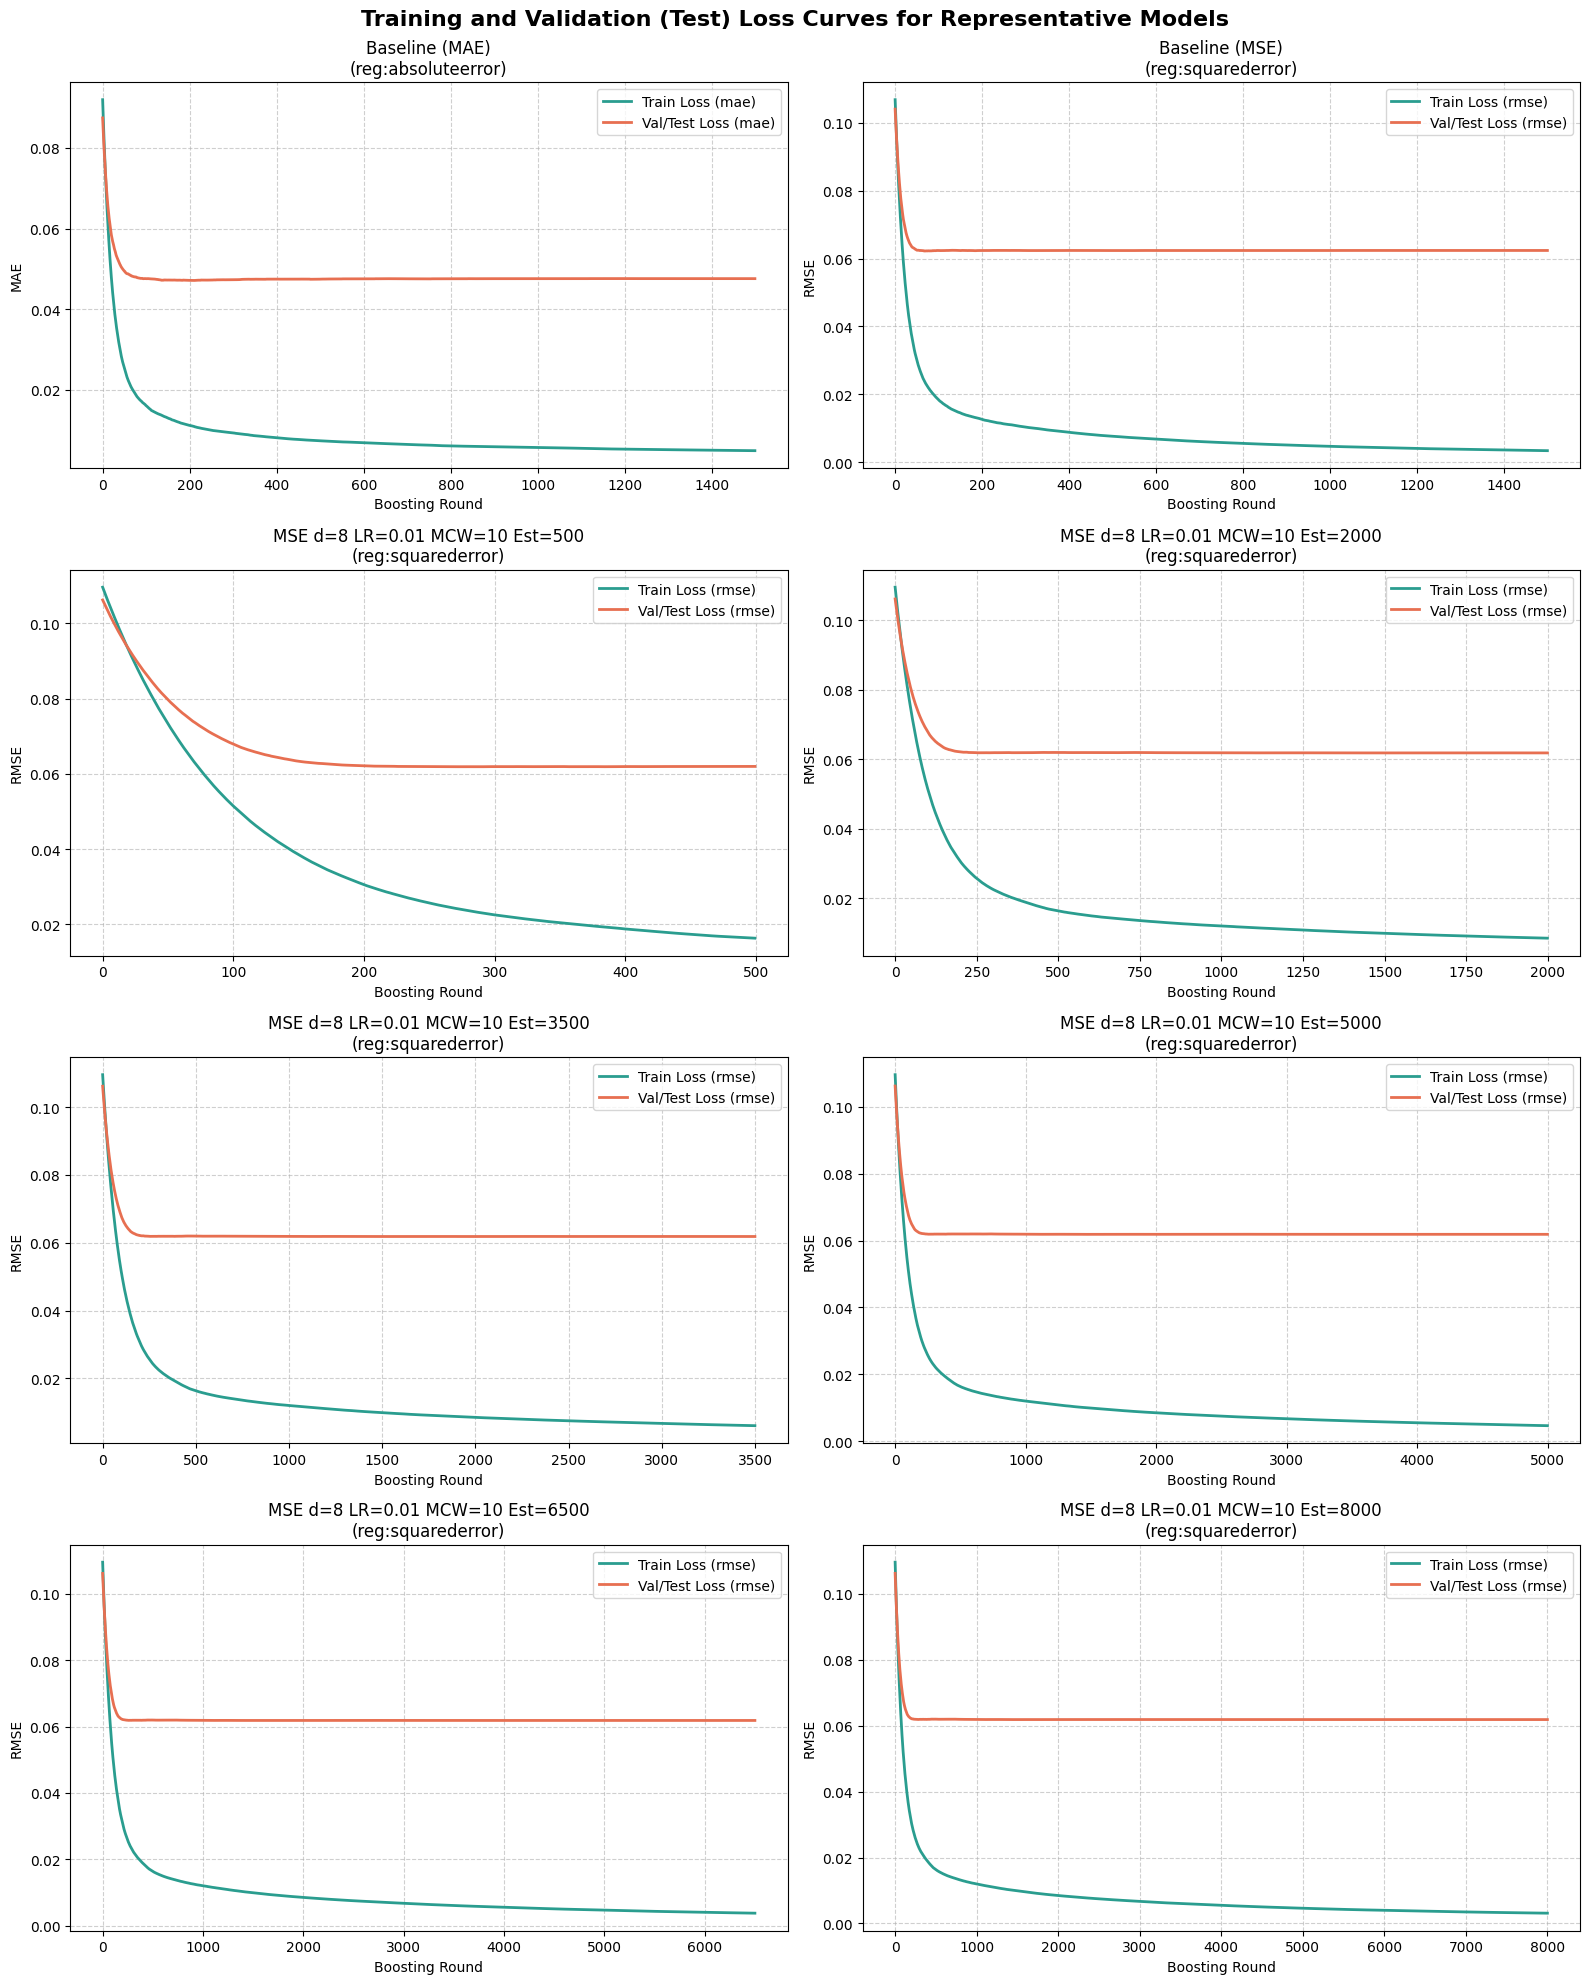

In [5]:
# Plot training vs validation loss curves for 8 selected representative models (4 rows, 2 columns)
selected_loss_models = [0, 1, 2, 5, 8, 11, 14, 17] # MAE, MSE, Est=500, 2000, 3500, 5000, 6500, 8000
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, mid in enumerate(selected_loss_models):
    config = next(c for c in MODELS_CONFIG if c["id"] == mid)
    model_name = config["name"]
    evals = evals_results[mid]
    metric_key = list(evals["validation_0"].keys())[0]
    
    train_loss = evals["validation_0"][metric_key]
    val_loss = evals["validation_1"][metric_key]
    
    ax = axes[i]
    ax.plot(train_loss, label=f"Train Loss ({metric_key})", color="#2a9d8f", linewidth=2)
    ax.plot(val_loss, label=f"Val/Test Loss ({metric_key})", color="#e76f51", linewidth=2)
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel(metric_key.upper())
    ax.set_title(f"{model_name}\n({config['objective']})")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

plt.suptitle("Training and Validation (Test) Loss Curves for Representative Models", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
plt.savefig(out_dir / "loss_curves.png", dpi=300)
plt.show()


# Section 5: Metric Evaluation & Timing Summary

In this section, we evaluate the overall performance of all 120 model configurations on the held-out test split. We compute key statistical metrics ($R^2$, RMSE, ubRMSE, Bias, MAE, Median Absolute Error, and Pearson correlation) along with the recorded training and inference times. The results are compiled into a unified comparison table and saved to `metrics_summary.csv`.


In [6]:
# Define compute_metrics utility
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson
    }

# Compile summary metrics
summary_records = []
for config in MODELS_CONFIG:
    model_id = config["id"]
    model_name = config["name"]
    preds = test_predictions_df[f"pred_{model_id}"]
    
    metrics = compute_metrics(y_test, preds)
    metrics["Configuration"] = model_name
    metrics["Train Time (s)"] = config["train_time_s"]
    metrics["Inference Time (s)"] = config["inference_time_s"]
    summary_records.append(metrics)

summary_df = pd.DataFrame(summary_records)
# Reorder columns
cols_order = ["Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson", "Train Time (s)", "Inference Time (s)"]
summary_df = summary_df[cols_order]

summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)
print("===== COMPARATIVE PERFORMANCE & TIMING SUMMARY =====")
print(summary_df.to_string(index=False, formatters={
    'R2': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'ubRMSE': '{:,.4f}'.format,
    'Bias': '{:+,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'Med|Err|': '{:,.4f}'.format,
    'Pearson': '{:,.4f}'.format,
    'Train Time (s)': '{:,.2f}'.format,
    'Inference Time (s)': '{:,.4f}'.format
}))

===== COMPARATIVE PERFORMANCE & TIMING SUMMARY =====
                  Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson Train Time (s) Inference Time (s)
                 Baseline (MAE) 0.6454 0.0627 0.0590 -0.0213 0.0476   0.0366  0.8314          11.87             0.1015
                 Baseline (MSE) 0.6492 0.0624 0.0588 -0.0209 0.0469   0.0355  0.8339          10.81             0.1216
 MSE d=8 LR=0.01 MCW=10 Est=500 0.6536 0.0620 0.0584 -0.0207 0.0465   0.0355  0.8357           3.52             0.0454
MSE d=8 LR=0.01 MCW=10 Est=1000 0.6546 0.0619 0.0583 -0.0208 0.0464   0.0352  0.8371           6.44             0.0655
MSE d=8 LR=0.01 MCW=10 Est=1500 0.6551 0.0618 0.0583 -0.0207 0.0464   0.0352  0.8373           9.41             0.1015
MSE d=8 LR=0.01 MCW=10 Est=2000 0.6550 0.0618 0.0583 -0.0207 0.0464   0.0352  0.8373          11.79             0.1346
MSE d=8 LR=0.01 MCW=10 Est=2500 0.6549 0.0619 0.0583 -0.0207 0.0464   0.0351  0.8373          15.02             0.

# Section 6: Overall Residual Plots

This section generates overall residuals comparison scatter plots for all 18 models in a 6x3 grid.


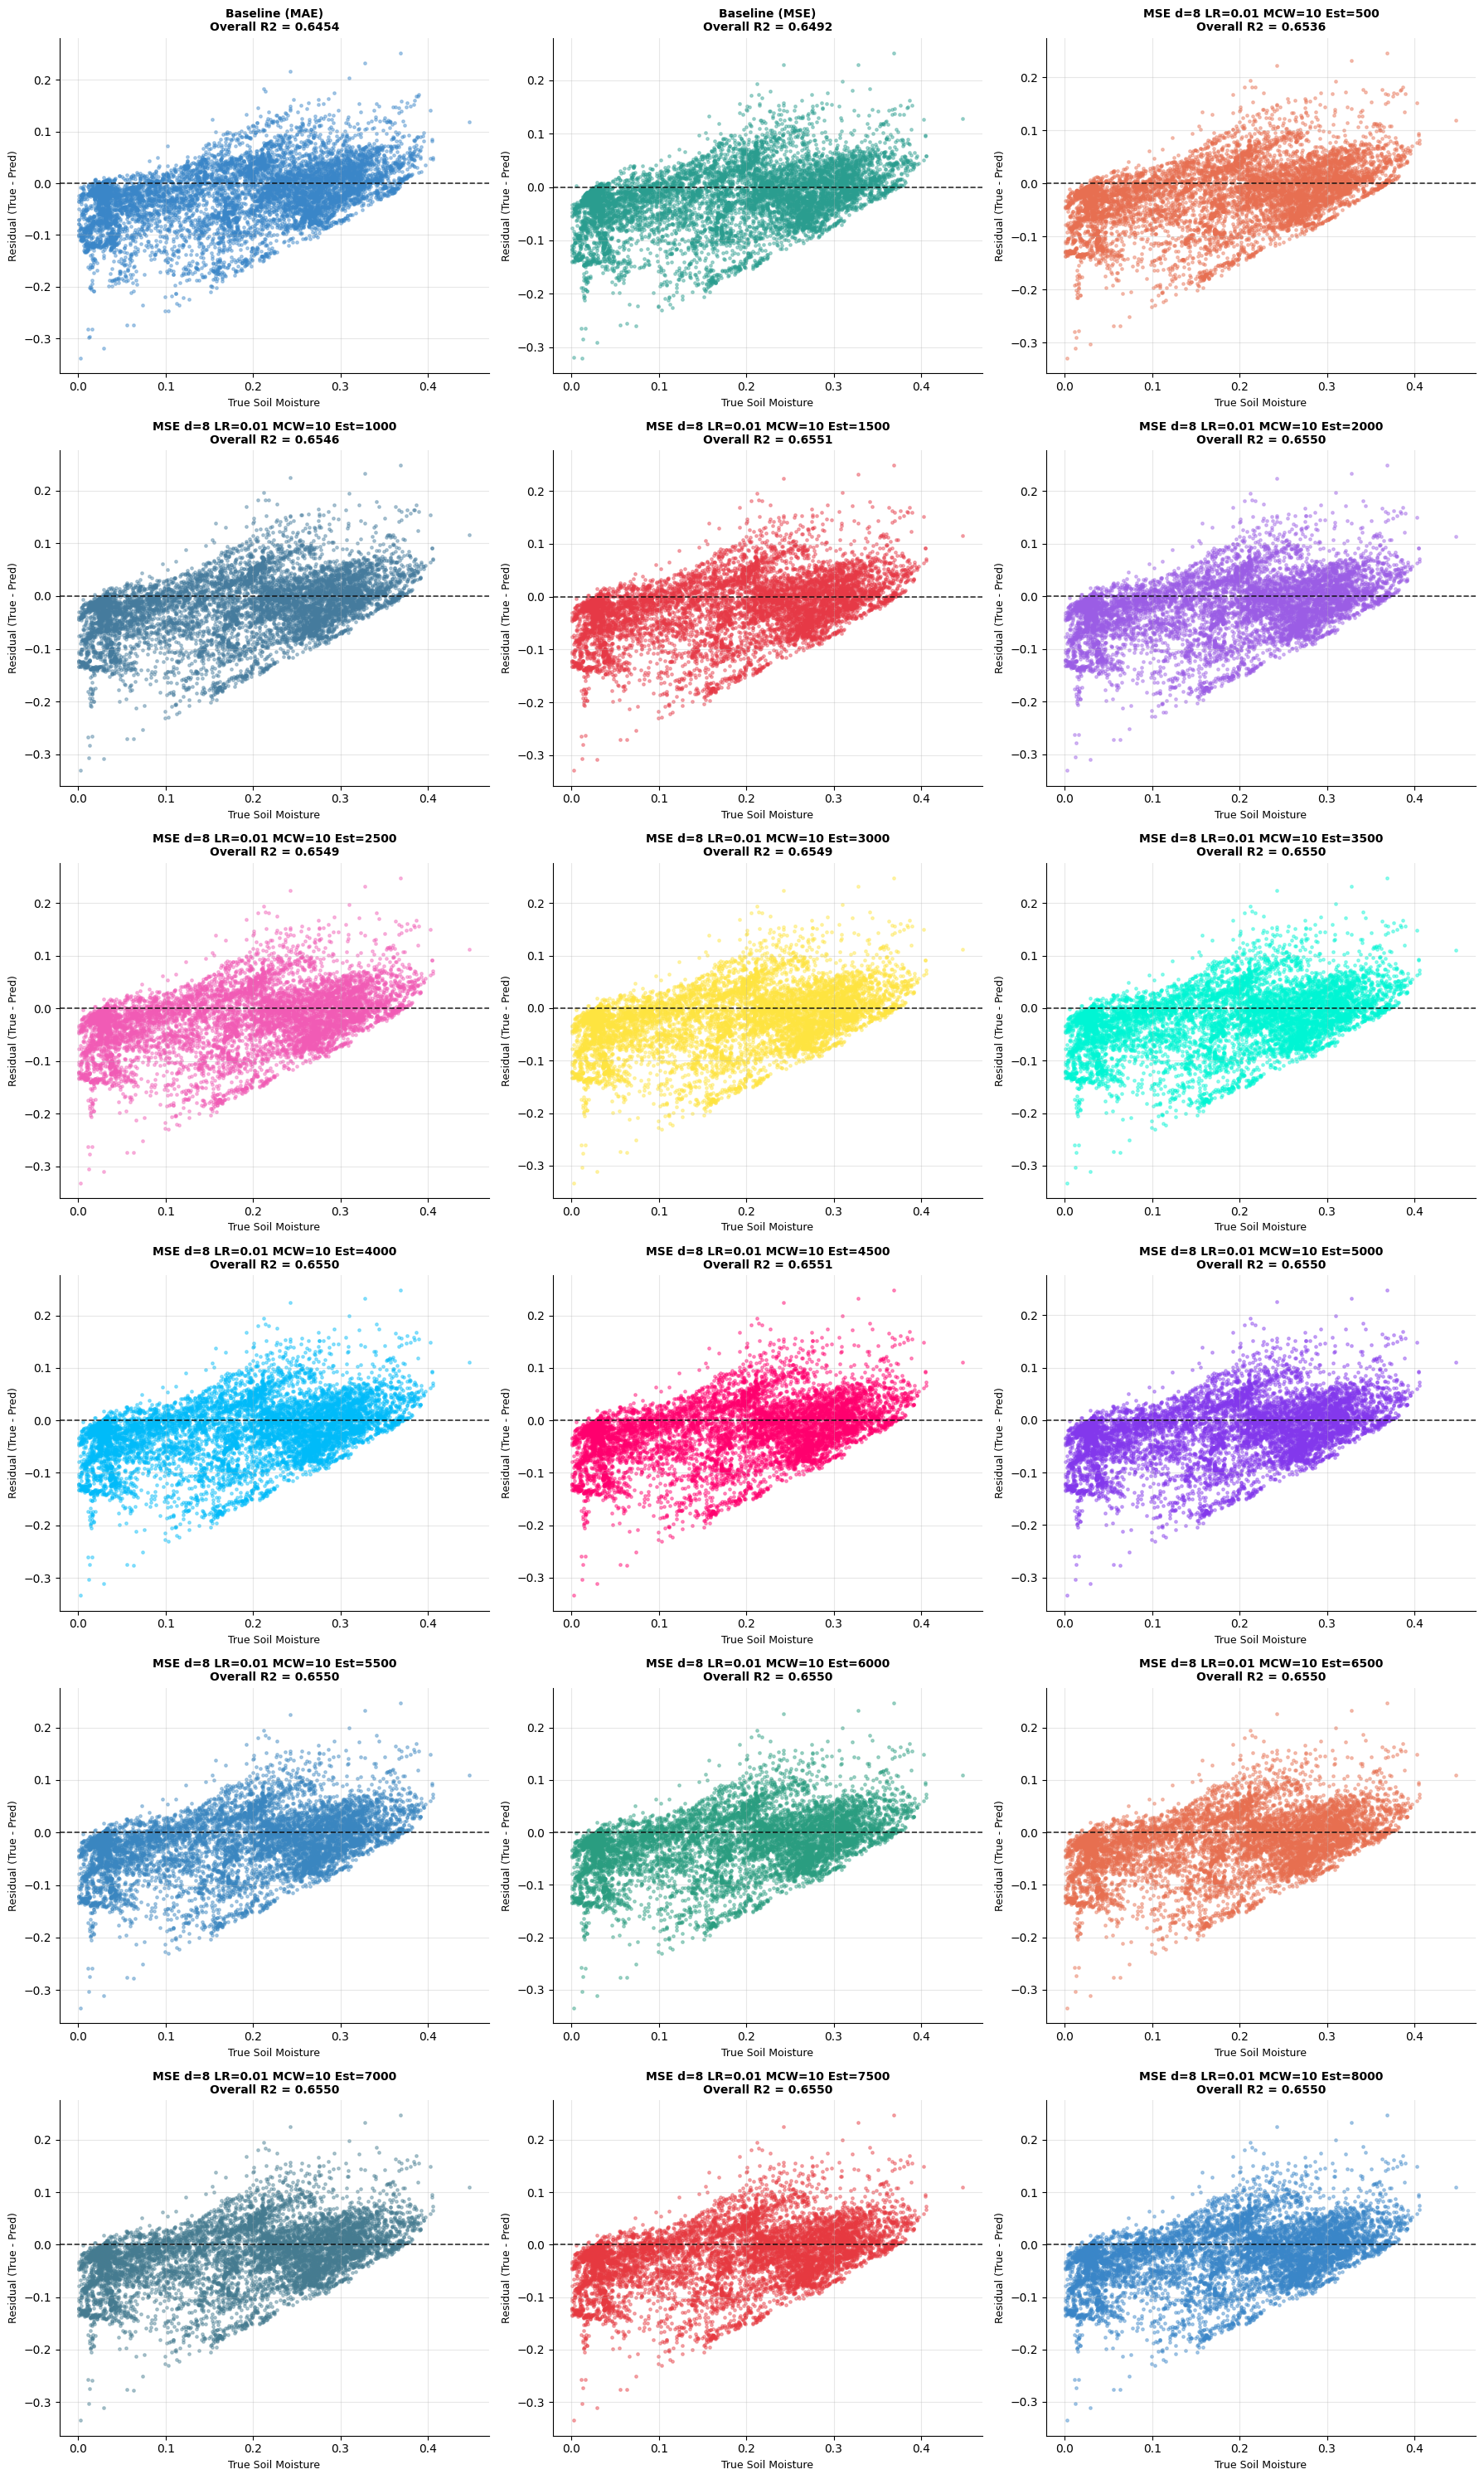

In [7]:
# Plot residuals comparison (6 rows, 3 columns = 18 axes)
fig, axes = plt.subplots(6, 3, figsize=(18, 30))
axes = axes.flatten()

# Curate some distinct colors for the plots
colors_palette = [
    '#3a86c8', '#2a9d8f', '#e76f51', '#457b9d', '#e63946', '#9b5de5', '#f15bb5', '#fee440', '#00f5d4',
    '#00bbf9', '#ff006e', '#8338ec', '#3a86c0', '#2a9d80', '#e76f50', '#457b90', '#e63940'
]

for i, config in enumerate(MODELS_CONFIG):
    model_id = config["id"]
    model_name = config["name"]
    preds = test_predictions_df[f"pred_{model_id}"]
    res = y_test - preds
    r2_val = r2_score(y_test, preds)
    
    ax = axes[i]
    ax.scatter(y_test, res, s=6, alpha=0.4, color=colors_palette[i % len(colors_palette)])
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_xlabel("True Soil Moisture", fontsize=9)
    ax.set_ylabel("Residual (True - Pred)", fontsize=9)
    ax.set_title(f"{model_name}\nOverall R2 = {r2_val:.4f}", fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide any remaining unused subplots (if any)
for j in range(len(MODELS_CONFIG), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(out_dir / "residuals_comparison.png", dpi=150)
plt.show()


# Section 7: Year-by-Year Performance Evaluation & Residuals

In this section, we evaluate each of the 120 configurations separately on each test year (2023, 2024, and 2025) to understand their temporal generalization consistency. We calculate yearly performance metrics and compile them into `metrics_by_year.csv`. To keep the visualization manageable and save memory, we select a representative subset of 7 configurations (representing the baselines and each sweep group) to plot the residuals by year in a 7x3 grid saved as `residuals_by_year.png`.


Test years identified: [np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]

===== YEAR 2023 BASELINES & SAMPLE PERFORMANCES =====
 Year                   Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
 2023                  Baseline (MAE) 0.6286 0.0656 0.0569 -0.0327 0.0509   0.0405  0.8505
 2023                  Baseline (MSE) 0.6421 0.0644 0.0565 -0.0308 0.0503   0.0406  0.8530
 2023 MSE d=8 LR=0.01 MCW=10 Est=1000 0.6581 0.0629 0.0551 -0.0303 0.0490   0.0402  0.8605
 2023 MSE d=8 LR=0.01 MCW=10 Est=2000 0.6577 0.0630 0.0552 -0.0302 0.0491   0.0406  0.8600
 2023 MSE d=8 LR=0.01 MCW=10 Est=4000 0.6566 0.0631 0.0553 -0.0302 0.0492   0.0406  0.8593
 2023 MSE d=8 LR=0.01 MCW=10 Est=8000 0.6560 0.0631 0.0554 -0.0302 0.0493   0.0406  0.8591

===== YEAR 2024 BASELINES & SAMPLE PERFORMANCES =====
 Year                   Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
 2024                  Baseline (MAE) 0.6427 0.0597 0.0572 -0.0171 0.0445   0.

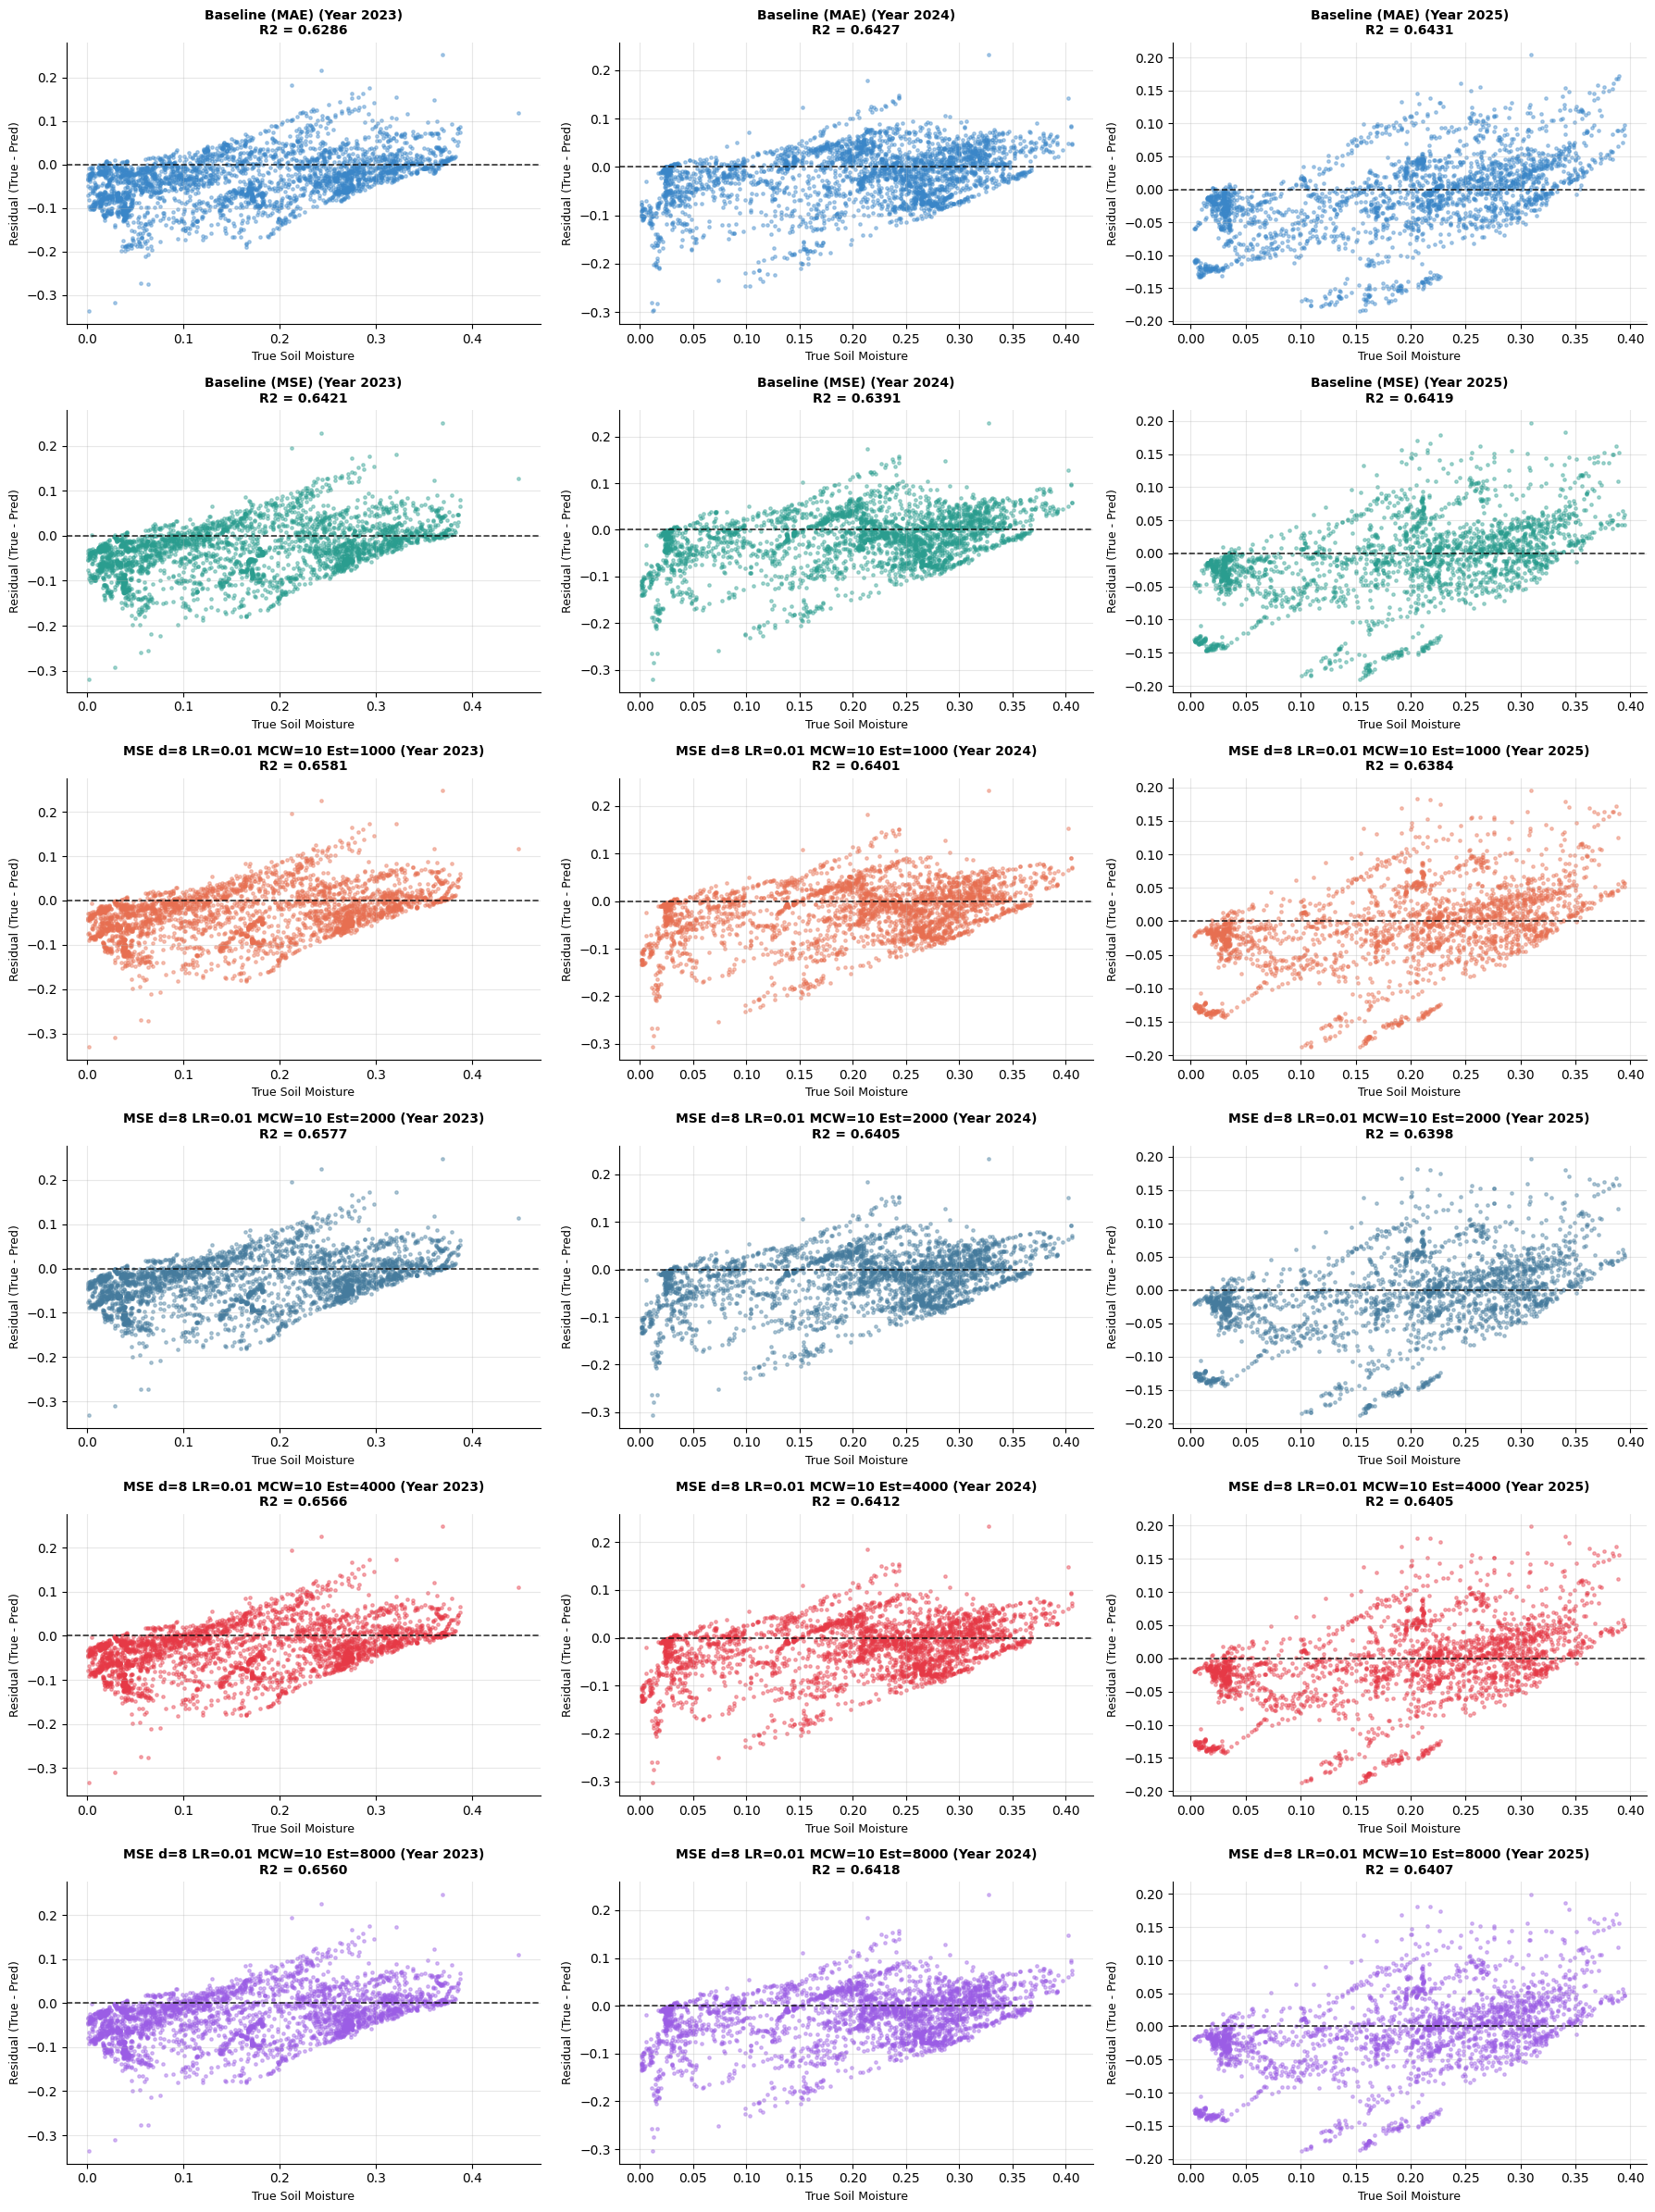

In [8]:
# Identify unique test years
test_years = sorted(test_predictions_df["year"].unique())
print(f"Test years identified: {test_years}")

yearly_records = []

for yr in test_years:
    df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
    y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
    
    for config in MODELS_CONFIG:
        model_id = config["id"]
        model_name = config["name"]
        preds_yr = test_predictions_df[test_predictions_df["year"] == yr][f"pred_{model_id}"].values
        
        metrics_yr = compute_metrics(y_test_yr, preds_yr)
        metrics_yr["Year"] = int(yr)
        metrics_yr["Configuration"] = model_name
        yearly_records.append(metrics_yr)

yearly_summary_df = pd.DataFrame(yearly_records)
# Reorder columns
cols_order_yr = ["Year", "Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson"]
yearly_summary_df = yearly_summary_df[cols_order_yr]

# Print yearly metrics breakdown for baseline models as a reference
for yr in test_years:
    print(f"\n===== YEAR {int(yr)} BASELINES & SAMPLE PERFORMANCES =====")
    df_yr_m = yearly_summary_df[(yearly_summary_df["Year"] == int(yr)) & (yearly_summary_df["Configuration"].isin([
        "Baseline (MAE)", "Baseline (MSE)", "MSE d=8 LR=0.01 MCW=10 Est=1000", "MSE d=8 LR=0.01 MCW=10 Est=2000", "MSE d=8 LR=0.01 MCW=10 Est=4000", "MSE d=8 LR=0.01 MCW=10 Est=8000"
    ]))]
    print(df_yr_m.to_string(index=False, formatters={
        'R2': '{:,.4f}'.format,
        'RMSE': '{:,.4f}'.format,
        'ubRMSE': '{:,.4f}'.format,
        'Bias': '{:+,.4f}'.format,
        'MAE': '{:,.4f}'.format,
        'Med|Err|': '{:,.4f}'.format,
        'Pearson': '{:,.4f}'.format
    }))

yearly_summary_df.to_csv(out_dir / "metrics_by_year.csv", index=False)

# Plot residuals by year for 6 selected representative models (6 rows, 3 columns = 18 axes)
selected_subset = [0, 1, 3, 5, 9, 17] # MAE, MSE, Est=1000, Est=2000, Est=4000, Est=8000
fig, axes = plt.subplots(len(selected_subset), 3, figsize=(18, 24))

# Curate colors matching the models
colors_palette = [
    '#3a86c8', '#2a9d8f', '#e76f51', '#457b9d', '#e63946', '#9b5de5'
]

for r_idx, model_id in enumerate(selected_subset):
    config = next(c for c in MODELS_CONFIG if c["id"] == model_id)
    model_name = config["name"]
    
    for col, yr in enumerate(test_years):
        df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
        y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
        preds_yr = test_predictions_df[test_predictions_df["year"] == yr][f"pred_{model_id}"].values
        res_yr = y_test_yr - preds_yr
        r2_yr = r2_score(y_test_yr, preds_yr)
        
        ax = axes[r_idx, col]
        ax.scatter(y_test_yr, res_yr, s=6, alpha=0.4, color=colors_palette[r_idx % len(colors_palette)])
        ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
        ax.set_xlabel("True Soil Moisture", fontsize=9)
        ax.set_ylabel("Residual (True - Pred)", fontsize=9)
        ax.set_title(f"{model_name} (Year {int(yr)})\nR2 = {r2_yr:.4f}", fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / "residuals_by_year.png", dpi=150)
plt.show()


# Section 8: Year-by-Year R2 Trend Visualization

We plot the R2 score as a function of the number of steps (n_estimators) for the winning configuration overall and by test year to analyze the shrinkage trend.


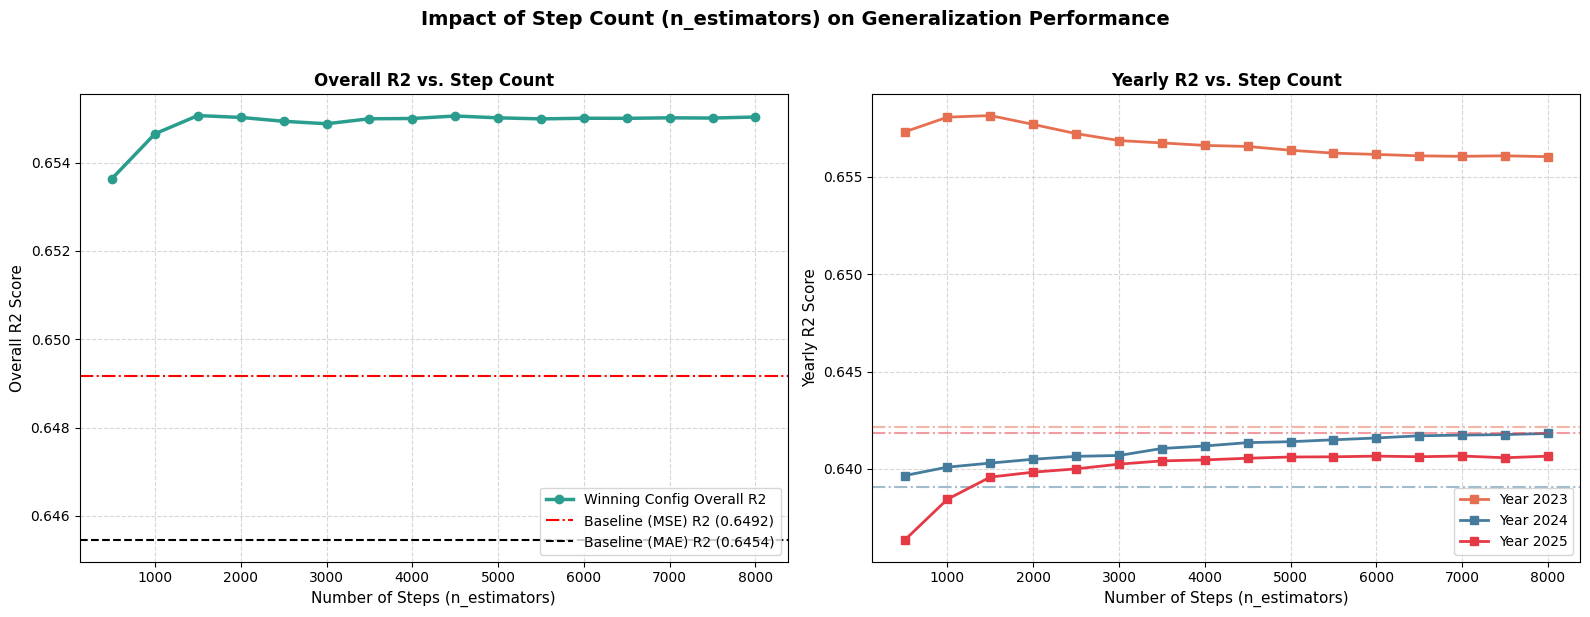

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Extract steps and overall metrics
steps = []
overall_r2 = []
yearly_r2 = {2023: [], 2024: [], 2025: []}

# Find step models (IDs 2-17)
step_models = [c for c in MODELS_CONFIG if c["id"] >= 2]
for config in step_models:
    model_name = config["name"]
    model_id = config["id"]
    est = config["n_estimators"]
    steps.append(est)
    
    # Overall R2
    r2_overall = summary_df[summary_df["Configuration"] == model_name]["R2"].values[0]
    overall_r2.append(r2_overall)
    
    # Yearly R2
    for yr in [2023, 2024, 2025]:
        r2_yr = yearly_summary_df[(yearly_summary_df["Configuration"] == model_name) & (yearly_summary_df["Year"] == yr)]["R2"].values[0]
        yearly_r2[yr].append(r2_yr)
        
# Plot Overall R2
axes[0].plot(steps, overall_r2, marker='o', linewidth=2.5, color='#2a9d8f', label='Winning Config Overall R2')
# Plot baselines as horizontal lines
base_mse_r2 = summary_df[summary_df["Configuration"] == "Baseline (MSE)"]["R2"].values[0]
base_mae_r2 = summary_df[summary_df["Configuration"] == "Baseline (MAE)"]["R2"].values[0]
axes[0].axhline(base_mse_r2, color='red', linestyle='-.', label=f'Baseline (MSE) R2 ({base_mse_r2:.4f})')
axes[0].axhline(base_mae_r2, color='black', linestyle='--', label=f'Baseline (MAE) R2 ({base_mae_r2:.4f})')

axes[0].set_xlabel("Number of Steps (n_estimators)", fontsize=11)
axes[0].set_ylabel("Overall R2 Score", fontsize=11)
axes[0].set_title("Overall R2 vs. Step Count", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right')

# Plot Yearly R2
colors = {2023: '#e76f51', 2024: '#457b9d', 2025: '#e63946'}
for yr in [2023, 2024, 2025]:
    axes[1].plot(steps, yearly_r2[yr], marker='s', linewidth=2, color=colors[yr], label=f'Year {yr}')
    # Baselines for the year
    base_mse_yr = yearly_summary_df[(yearly_summary_df["Configuration"] == "Baseline (MSE)") & (yearly_summary_df["Year"] == yr)]["R2"].values[0]
    axes[1].axhline(base_mse_yr, color=colors[yr], linestyle='-.', alpha=0.5)
    
axes[1].set_xlabel("Number of Steps (n_estimators)", fontsize=11)
axes[1].set_ylabel("Yearly R2 Score", fontsize=11)
axes[1].set_title("Yearly R2 vs. Step Count", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle("Impact of Step Count (n_estimators) on Generalization Performance", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(out_dir / "r2_by_year.png", dpi=300, bbox_inches='tight')
plt.show()
